In [37]:
import numpy as np
import matplotlib.pyplot as plt


def plot_rosenbrock_density(
    a: float = 1.0,
    b: float = 100.0,
    *,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
    grid_size: int = 200,
    ax=None,
    cmap: str = "viridis",
):
    """Heatmap of the Rosenbrock-shaped density exp(-f(x,y)/20)."""
    if b <= 0:
        raise ValueError("b must be positive")

    # Using exp(-f/20) corresponds to 2*sigma^2 = 20 => sigma^2 = 10
    sigma2 = 10.0
    sigma = np.sqrt(sigma2)

    if xlim is None:
        xlim = (a - 4 * sigma, a + 4 * sigma)
    if ylim is None:
        y_std = sigma / np.sqrt(b)
        ylim = (-1.0, 20.0)

    xs = np.linspace(xlim[0], xlim[1], grid_size)
    ys = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(xs, ys)

    f = (a - X) ** 2 + b * (Y - X**2) ** 2
    Z = np.exp(-f / 20.0)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 5.0))
    else:
        fig = ax.figure

    im = ax.imshow(
        Z,
        origin="lower",
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        aspect="auto",
        cmap=cmap,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Rosenbrock density exp(-f/20) (a={a}, b={b})")
    fig.colorbar(im, ax=ax, label="unnormalized density")
    return fig, ax

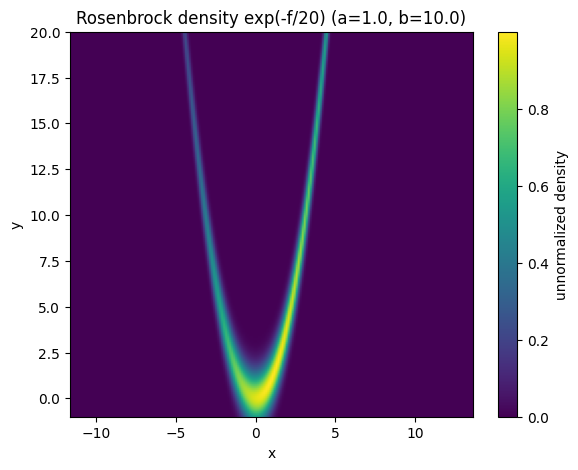

In [38]:
# Example usage
fig, ax = plot_rosenbrock_density(a=1.0, b=10.0)
plt.show()